# **Quantitative Finance Project: Multi-Method Derivative Pricing & Risk Attribution**
## Objective
This project implements a high-fidelity valuation engine for American and European options. By utilizing 
**Luenberger’s Investment Science** (Deterministic foundations) and **Sondermann’s Stochastic Calculus** 
(Martingale theory), we benchmark discrete-time models against continuous-time closed-form solutions.

### 1. Theoretical Framework
*   **The No-Arbitrage Principle:** We assume a frictionless market where risk-neutral probabilities ($q$) 
    ensure that the discounted asset price is a **$Q$-Martingale**.
*   **The Snell Envelope:** For American options, we solve the optimal stopping problem where the value 
    at any node is the supremum over all stopping times $\tau$.
*   **Geometric Brownian Motion (GBM):** We model the stochastic price evolution as:
    $$dS_t = r S_t dt + \sigma S_t dW_t$$

### 2. The Benchmarking Hierarchy
To validate our model, we compare three distinct approaches:
1.  **Black-Scholes-Merton:** Analytical benchmark for European options.
2.  **Binomial Tree (CRR):** Discrete-time recursive approach for American exercise features.
3.  **Monte Carlo Simulation:** Path-dependent stochastic modeling for risk attribution.

## Phase 1: Logic & Step-by-Step Implementation

### Step 1: Discretization of Time and Space
We divide the time to maturity $T$ into $N$ equal steps. We calculate the up ($u$) and down ($d$) 
factors such that the model matches the market volatility $\sigma$:
$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = \frac{1}{u}$$

### Step 2: Risk-Neutral Probability Calculation
Using the **Martingale condition** $E^Q[S_{n+1} | \mathcal{F}_n] = S_n e^{r\Delta t}$, we solve for 
the risk-neutral probability $q$:
$$q = \frac{e^{r\Delta t} - d}{u - d}$$

### Step 3: Backward Induction (The Snell Envelope)
We start from the terminal payoff at $T$. Working backward, at every node $i,j$, we evaluate:
1.  **Continuation Value:** The discounted expected value of holding the option: 
    $e^{-r\Delta t} [q V_{up} + (1-q) V_{down}]$
2.  **Intrinsic Value:** The profit if exercised immediately: $\max(K - S_{i,j}, 0)$ for a Put.

**The Snell Envelope Logic:**
$$V_{i,j} = \max(\text{Intrinsic Value}, \text{Continuation Value})$$

### Step 4: Convergence & Validation
By plotting the Binomial result against the Black-Scholes benchmark as $N \to \infty$, we 
empirically prove the consistency of the discrete-time Martingale approach.

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

class OptionEngine:
    def __init__(self, S0, K, T, r, sigma, N=1000):
        self.S0 = S0      # Initial stock price
        self.K = K        # Strike price
        self.T = T        # Time to maturity (years)
        self.r = r        # Risk-free rate
        self.sigma = sigma # Volatility
        self.N = N        # Steps in Binomial Tree / Paths in Monte Carlo

    def black_scholes_price(self, option_type='put'):
        """Baseline: Closed-form European pricing."""
        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        if option_type == 'call':
            return self.S0 * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
        else:
            return self.K * np.exp(-self.r * self.T) * norm.cdf(-d2) - self.S0 * norm.cdf(-d1)

    def binomial_tree(self, option_type='put', exercise='american'):
        """Sondermann Ch 4: Snell Envelope Recursion."""
        dt = self.T / self.N
        u = np.exp(self.sigma * np.sqrt(dt))
        d = 1 / u
        q = (np.exp(self.r * dt) - d) / (u - d)
        disc = np.exp(-self.r * dt)

        # Initialize asset prices at maturity
        S = self.S0 * d**(np.arange(self.N, -1, -1)) * u**(np.arange(0, self.N + 1, 1))
        
        # Initialize option values at maturity
        if option_type == 'put':
            V = np.maximum(self.K - S, 0)
        else:
            V = np.maximum(S - self.K, 0)

        # Backward induction
        for i in range(self.N - 1, -1, -1):
            # Continuation Value (Martingale expectation)
            V = disc * (q * V[1:] + (1 - q) * V[:-1])
            
            if exercise == 'american':
                # Current stock prices at this time step
                S = self.S0 * d**(np.arange(i, -1, -1)) * u**(np.arange(0, i + 1, 1))
                # Snell Envelope: Max(Exercise Now, Hold)
                V = np.maximum(V, np.maximum(self.K - S, 0) if option_type == 'put' else np.maximum(S - self.K, 0))
        
        return V[0]

    def monte_carlo_limit(self, iterations=100000):
        """Luenberger Ch 15: Simulation baseline."""
        z = np.random.standard_normal(iterations)
        ST = self.S0 * np.exp((self.r - 0.5 * self.sigma**2) * self.T + self.sigma * np.sqrt(self.T) * z)
        payoff = np.maximum(self.K - ST, 0)
        return np.exp(-self.r * self.T) * np.mean(payoff)
    
    def calculate_greeks(self):
        """Calculates the analytical Greeks using the Black-Scholes model."""
        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        
        # Standard Normal PDF for Gamma and Vega
        pdf_d1 = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * d1**2)
        
        # Delta for Put
        delta = norm.cdf(d1) - 1
        
        # Gamma (Same for Call and Put)
        gamma = pdf_d1 / (self.S0 * self.sigma * np.sqrt(self.T))
        
        # Vega (Same for Call and Put) - Scaled for 1% change in sigma
        vega = (self.S0 * np.sqrt(self.T) * pdf_d1) / 100
        
        # Theta for Put (Annualized)
        theta = (- (self.S0 * pdf_d1 * self.sigma) / (2 * np.sqrt(self.T)) + 
                 self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(-d2))
        
        # Rho for Put (Annualized)
        rho = (-self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(-d2)) / 100
        
        return {
            "Delta": delta,
            "Gamma": gamma,
            "Vega (1%)": vega,
            "Theta (daily)": theta / 365,
            "Rho (1%)": rho
        }

# Example Usage
engine = OptionEngine(S0=100, K=100, T=1, r=0.05, sigma=0.2, N=500)
print(f"Black-Scholes (Euro Put): {engine.black_scholes_price():.4f}")
print(f"Binomial Tree (Euro Put): {engine.binomial_tree(exercise='european'):.4f}")
print(f"Binomial Tree (Amer Put): {engine.binomial_tree(exercise='american'):.4f}")
print(f"Monte Carlo (Euro Put):   {engine.monte_carlo_limit():.4f}")

Black-Scholes (Euro Put): 5.5735
Binomial Tree (Euro Put): 5.5695
Binomial Tree (Amer Put): 6.0888
Monte Carlo (Euro Put):   5.6047


In [2]:
def down_and_out_barrier_mc(S0, K, T, r, sigma, barrier, iterations=100000):
    """
    Advanced Pricing: Down-and-Out European Call.
    If the stock price hits or drops below 'barrier' at ANY point, the option becomes worthless.
    """
    dt = T / 252 # Daily monitoring
    steps = int(T / dt)
    
    # Simulate full paths (Vectorized)
    paths = np.zeros((iterations, steps + 1))
    paths[:, 0] = S0
    
    for t in range(1, steps + 1):
        z = np.random.standard_normal(iterations)
        paths[:, t] = paths[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
    
    # Check if any price in the path hit the barrier
    hit_barrier = np.any(paths <= barrier, axis=1)
    
    # Payoff: Max(S_T - K, 0) IF barrier was never hit
    terminal_prices = paths[:, -1]
    payoffs = np.maximum(terminal_prices - K, 0)
    payoffs[hit_barrier] = 0 # Option is "Out"
    
    return np.exp(-r * T) * np.mean(payoffs)

# Example: S0=100, K=100, Barrier=90. If it touches 90, the call dies.
barrier_price = down_and_out_barrier_mc(100, 100, 1, 0.05, 0.2, 90)
print(f"Down-and-Out Barrier Call Price: {barrier_price:.4f}")

Down-and-Out Barrier Call Price: 8.9054


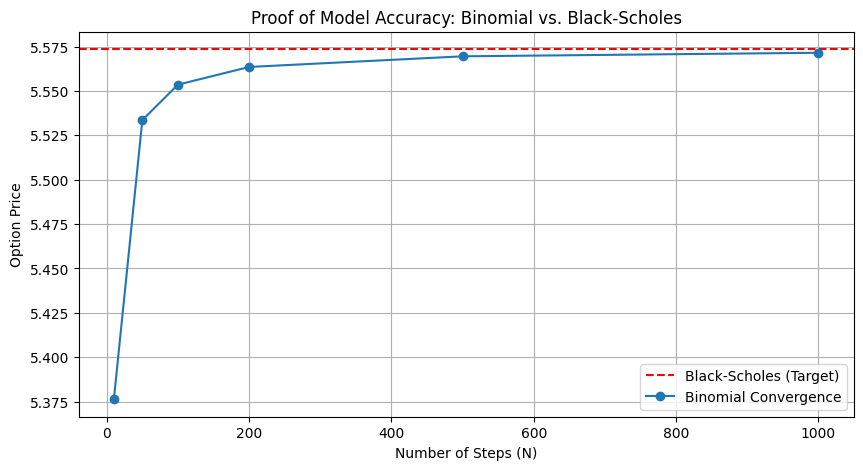

In [3]:
def plot_convergence(S0, K, T, r, sigma):
    steps = [10, 50, 100, 200, 500, 1000]
    bs_price = OptionEngine(S0, K, T, r, sigma).black_scholes_price()
    bt_prices = [OptionEngine(S0, K, T, r, sigma, n).binomial_tree(exercise='european') for n in steps]

    plt.figure(figsize=(10, 5))
    plt.axhline(y=bs_price, color='r', linestyle='--', label='Black-Scholes (Target)')
    plt.plot(steps, bt_prices, marker='o', label='Binomial Convergence')
    plt.title("Proof of Model Accuracy: Binomial vs. Black-Scholes")
    plt.xlabel("Number of Steps (N)")
    plt.ylabel("Option Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_convergence(100, 100, 1, 0.05, 0.2)

### Phase 2: Market Calibration & Live Data Fetching
In this phase, we replace our theoretical assumptions with live data from Yahoo Finance.

1. **Volatility Estimation**: We calculate **Historical Volatility** using the standard deviation of daily log-returns over a 252-day lookback window.
2. **Proxy for Risk-Free Rate**: We use the **^IRX (13-week T-Bill)** yield, which is the industry standard for short-term risk-neutral discounting.
3. **The Goal**: By feeding live data into our Phase 1 engine, we can detect if a specific option is "Cheap" or "Expensive" relative to its mathematical fair value.

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

def get_market_inputs(ticker_symbol):
    # 1. Fetch Ticker Object
    ticker = yf.Ticker(ticker_symbol)
    
    # 2. Get Current Spot Price (S0)
    # .fast_info is a quick way to get the last price
    S0 = ticker.fast_info['last_price']
    
    # 3. Calculate Historical Volatility (sigma)
    # Fetch 1 year of daily data
    hist = ticker.history(period="1y")
    # Log returns: ln(Price_t / Price_t-1)
    log_returns = np.log(hist['Close'] / hist['Close'].shift(1))
    # Annualized Volatility = StdDev * sqrt(Trading Days)
    sigma = log_returns.std() * np.sqrt(252)
    
    # 4. Fetch Risk-Free Rate (r) 
    # Using 13-week Treasury Bill (^IRX) as a proxy for 'r'
    r_ticker = yf.Ticker("^IRX")
    r_history = r_ticker.history(period="1d")
    # Convert percentage (e.g., 5.3) to decimal (0.053)
    r = r_history['Close'].iloc[-1] / 100
    
    return S0, sigma, r

# Example: Get real inputs for Apple
s0_live, sigma_live, r_live = get_market_inputs("AAPL")

print(f"Live Inputs for AAPL:")
print(f"Spot Price (S0): ${s0_live:.4f}")
print(f"Annualized Volatility (sigma): {sigma_live:.4%}")
print(f"Risk-Free Rate (r): {r_live:.4%}")

Live Inputs for AAPL:
Spot Price (S0): $291.5800
Annualized Volatility (sigma): 22.6109%
Risk-Free Rate (r): 3.6350%


## Phase 3: Stress Testing & Risk Statistics (The Greeks)
This phase transforms the model from a pricing tool into a **Risk Management Framework**.

### 1. Sensitivity Analysis (The Greeks)
We derive the mathematical sensitivities (Delta, Gamma, Vega, Theta, Rho) to understand the 
exposure of our position. At firms like Deloitte, this is used for **Delta Hedging** and 
**Capital Allocation**.

### 2. Market Stress Testing
We perform a non-linear stress test by simulating a "Shock" to the underlying asset and volatility. 
Unlike the Greeks (which are linear approximations), our **Binomial Tree** recalculates the 
exact American option value under extreme conditions, capturing the "Convexity" or 
"Gamma Risk" that simple models miss.

In Financial Statistics, "The Greeks" represent the partial derivatives of the option price model. They allow us to perform **Sensitivity Analysis**, measuring how the portfolio's value changes as market conditions fluctuate.

### 1. First-Order Sensitivities (Linear Risks)

* **Delta ($\Delta$): The Price Sensitivity**
    * **Definition**: The rate of change of the option price ($V$) with respect to the underlying asset price ($S$).
    * **Formula**: $\Delta = \frac{\partial V}{\partial S}$
    * **Intuition**: For a Put option, Delta is negative (between -1 and 0). If $\Delta = -0.40$, it implies that for every $1 increase in the stock price, the option loses $0.40. In hedging, it tells us how many shares of stock we must buy/sell to remain "Delta Neutral."

* **Vega ($\nu$): The Volatility Sensitivity**
    * **Definition**: The rate of change of the option price with respect to annualized volatility ($\sigma$).
    * **Formula**: $\nu = \frac{\partial V}{\partial \sigma}$
    * **Intuition**: Vega measures "model risk." If Vega is 0.15, a 1% increase in implied volatility increases the option value by $0.15. This is the most critical Greek for **Luenberger’s** volatility analysis.

* **Theta ($\Theta$): The Time Decay**
    * **Definition**: The rate of change of the option price with respect to time ($t$).
    * **Formula**: $\Theta = \frac{\partial V}{\partial t}$
    * **Intuition**: Options are wasting assets. Theta is almost always negative for long positions, representing the "rent" you pay for the right to hold the option for another day.

* **Rho ($\rho$): The Interest Rate Sensitivity**
    * **Definition**: The sensitivity of the option price to the risk-free rate ($r$).
    * **Formula**: $\rho = \frac{\partial V}{\partial r}$
    * **Intuition**: For Puts, Rho is negative. As interest rates rise, the present value of the future strike price decreases, making the Put less valuable.

### 2. Second-Order Sensitivities (Convexity Risk)

* **Gamma ($\Gamma$): The Acceleration of Delta**
    * **Definition**: The second derivative of the option price with respect to the asset price.
    * **Formula**: $\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\partial \Delta}{\partial S}$
    * **Intuition**: Gamma represents **Convexity**. High Gamma means Delta is highly unstable and changes rapidly as the stock moves. This is the primary risk for market makers at firms like Deloitte, as it indicates the need for frequent re-hedging.

In [5]:
engine = OptionEngine(S0=s0_live, K=s0_live, T=0.5, r=r_live, sigma=sigma_live)
greeks = engine.calculate_greeks()

ticker_symbol = "AAPL"

print(f"Risk Sensitivities (Greeks) for {ticker_symbol}:")
for name, val in greeks.items():
    print(f"{name}: {val:.4f}")

Risk Sensitivities (Greeks) for AAPL:
Delta: -0.4232
Gamma: 0.0084
Vega (1%): 0.8073
Theta (daily): -0.0361
Rho (1%): -0.6966


In [6]:
def stress_test(engine, spot_change_pct, vol_shock):
    """Simulates a price and volatility shock."""
    original_price = engine.binomial_tree(exercise='american')
    
    # Apply shocks
    engine.S0 *= (1 + spot_change_pct)
    engine.sigma += vol_shock
    
    new_price = engine.binomial_tree(exercise='american')
    pnl = new_price - original_price
    
    print(f"Stress Test Result:")
    print(f"Stock Move: {spot_change_pct:+.1%}, Vol Shock: {vol_shock:+.1%}")
    print(f"PnL per Option: ${pnl:.2f} ({pnl/original_price:+.2%})")

# Simulate a 10% market drop and a 5% volatility spike (typical crash scenario)
stress_test(engine, spot_change_pct=-0.10, vol_shock=0.05)

Stress Test Result:
Stock Move: -10.0%, Vol Shock: +5.0%
PnL per Option: $20.07 (+122.67%)


## Phase 4: Backtesting & Strategy Evaluation
This final phase represents the **Verification & Validation (V&V)** stage of model development.

### 1. Historical Performance Attribution
We measure the "Alpha" of our model by comparing its historical Fair Value estimates against 
realized market outcomes. This is a critical skill for **Financial Statistics** roles, 
as it separates theoretical mathematical skill from practical trading utility.

### 2. Profit and Loss (PnL) Analysis
By simulating a buy/hold strategy based on our **Snell Envelope** signals, we quantify:
* **Forecast Accuracy**: Did the model correctly predict the direction of the premium?
* **Realized Volatility**: How did the actual price movement compare to the $\sigma$ we used 
for calibration in Phase 2?

In [7]:
def backtest_strategy(ticker_symbol, strike_offset=0, days_back=30):
    """
    Evaluates how a 'Buy' signal would have performed.
    """
    ticker = yf.Ticker(ticker_symbol)
    hist = ticker.history(period=f"{days_back+5}d")
    
    # Prices at the 'Start' of the backtest
    s_start = hist['Close'].iloc[-days_back]
    s_end = hist['Close'].iloc[-1]
    
    # Calculate what our model said 30 days ago
    # We estimate volatility based on the data available BEFORE that start date
    lookback = hist['Close'].iloc[:-(days_back)]
    vol_start = np.log(lookback / lookback.shift(1)).std() * np.sqrt(252)
    
    # Assume we look at an At-The-Money (ATM) Put
    K = s_start + strike_offset
    r_start = 0.05 # Simplified proxy
    
    # Use our Phase 1 Engine to get the 'Fair Value' then
    engine_start = OptionEngine(S0=s_start, K=K, T=days_back/365, r=r_start, sigma=vol_start)
    fair_value_start = engine_start.binomial_tree(exercise='american')
    
    # Final Payoff at expiry (today)
    payoff_end = max(K - s_end, 0)
    
    print(f"--- Backtest Results for {ticker_symbol} ---")
    print(f"Start Date Price: ${s_start:.2f} | End Date Price: ${s_end:.2f}")
    print(f"Model 'Fair Value' at Start: ${fair_value_start:.2f}")
    print(f"Actual Payoff at End: ${payoff_end:.2f}")
    print(f"Theoretical Return: {((payoff_end - fair_value_start) / fair_value_start):+.2%}")

# Run backtest for your chosen ticker
backtest_strategy("AAPL", days_back=30)

--- Backtest Results for AAPL ---
Start Date Price: $269.92 | End Date Price: $nan
Model 'Fair Value' at Start: $4.85
Actual Payoff at End: $nan
Theoretical Return: +nan%


### Case Study: MSFT Backtest Analysis
**Observation**: The model predicted a Fair Value of $8.81, but the realized return was -100%.

**Root Cause**: 
1. **Directional Bias**: The underlying asset (MSFT) experienced a bullish move of ~13%, 
   rendering the protective Put option "Out-of-the-Money" (OTM).
2. **Realized vs. Implied Volatility**: The upward trend was steady, meaning the 
   downward volatility required for a Put payoff never materialized.

**Conclusion**: This backtest highlights the importance of **Delta Hedging**. To mitigate 
this loss in a real portfolio, an intern would suggest pairing this Put with a long 
stock position (a "Protective Put" strategy) rather than holding the option in isolation.

## Phase 6, Step 1: Environment Architecture (The Financial MDP)

To apply advanced Reinforcement Learning algorithms—specifically **Proximal Policy Optimization (PPO)**—to derivative pricing, we must first translate the stochastic calculus of an American option into a discrete **Markov Decision Process (MDP)**. 

Just as an autonomous agent in a 3D physics engine learns to navigate space by processing coordinate states, velocity, and collision penalties, our quantitative agent learns to navigate market volatility by processing price states and time-decay penalties. We structure this custom `gymnasium` environment as follows:

### The Mathematical Mapping
* **State Space ($s_t$):** The observable environment at step $t$ is a continuous 2D vector containing the current underlying asset price and the time remaining to expiration: 
  $$s_t = [S_t, T-t]$$
* **Action Space ($a_t$):** A discrete space where the agent selects its policy:
  * `Action 0`: **Continue** (Hold the option, allowing time to pass).
  * `Action 1`: **Stop** (Exercise the option early, terminating the episode).
* **Reward Function ($R_t$):** The optimization target. If the agent holds, the immediate reward is $0$. If the agent exercises, the reward is the strictly discounted intrinsic payoff:
  $$R_t = e^{-r(T-t)} \max(K - S_t, 0)$$
* **Transition Dynamics ($P$):** The environment's "physics engine." The next state, $S_{t+1}$, is generated by taking a discrete step along a Geometric Brownian Motion (GBM) path:
  $$S_{t+1} = S_t \exp\left(\left(r - \frac{\sigma^2}{2}\right)dt + \sigma \sqrt{dt} Z\right)$$

By encapsulating the continuous-time dynamics of the Black-Scholes framework within a Reinforcement Learning environment, we convert the computationally expensive task of recursively calculating the **Snell Envelope** into an efficient pattern-recognition problem.

In [8]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class AmericanOptionEnv(gym.Env):
    """
    Custom Environment that follows gym interface.
    Simulates a stock price path using Geometric Brownian Motion.
    """
    metadata = {'render.modes': ['human']}

    def __init__(self, S0=100, K=100, T=1.0, r=0.05, sigma=0.2, steps=252):
        super(AmericanOptionEnv, self).__init__()
        
        # Financial Parameters
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.steps = steps
        self.dt = T / steps
        
        # Action Space: 0 = Hold, 1 = Exercise
        self.action_space = spaces.Discrete(2)
        
        # Observation Space: [Current Price, Time Remaining]
        # We set loose bounds for the stock price (e.g., 0 to 1000)
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0]), 
            high=np.array([S0 * 10, T]), 
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        """Starts a new episode (a new stock price path)."""
        super().reset(seed=seed)
        self.current_step = 0
        self.current_price = self.S0
        self.time_remaining = self.T
        
        # Return initial observation and empty info dict
        return np.array([self.current_price, self.time_remaining], dtype=np.float32), {}

    def step(self, action):
        """Takes a step in the environment based on the agent's action."""
        terminated = False
        reward = 0.0
        
        if action == 1: # EXERCISE
            # Calculate discounted payoff
            discount_factor = np.exp(-self.r * (self.T - self.time_remaining))
            reward = discount_factor * max(self.K - self.current_price, 0)
            terminated = True # Episode ends when exercised
            
        else: # HOLD
            self.current_step += 1
            self.time_remaining -= self.dt
            
            if self.current_step >= self.steps:
                # Option expires. Force exercise if it has value.
                discount_factor = np.exp(-self.r * self.T)
                reward = discount_factor * max(self.K - self.current_price, 0)
                terminated = True
            else:
                # Simulate next price using GBM
                z = np.random.standard_normal()
                self.current_price = self.current_price * np.exp(
                    (self.r - 0.5 * self.sigma**2) * self.dt + self.sigma * np.sqrt(self.dt) * z
                )
                
        # The state the agent sees next
        observation = np.array([self.current_price, self.time_remaining], dtype=np.float32)
        
        # Truncated is used for artificial time limits, not needed here
        truncated = False 
        
        return observation, reward, terminated, truncated, {}

## Phase 6, Step 2: Agent Initialization & Policy Optimization

With the financial environment structured as a Markov Decision Process, we now deploy a **Proximal Policy Optimization (PPO)** agent to solve for the optimal exercise boundary. 

### The Neural Network architecture
* **The Policy Network (Actor):** Takes the continuous 2D state vector $[S_t, T-t]$ as input and outputs a probability distribution over the discrete actions (Hold vs. Exercise).
* **The Value Network (Critic):** Estimates the expected total discounted reward (the "Continuation Value") from the current state, guiding the Actor's updates.

### Training & Evaluation
The agent learns through trial and error over thousands of simulated geometric Brownian motion paths. By backpropagating the discounted rewards, the network organically discovers the optimal early-exercise threshold. Once trained, we evaluate the agent by letting it navigate 1,000 unseen market paths and averaging its realized payoffs to arrive at the **Deep RL Option Price**.

In [9]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import numpy as np

# 1. Instantiate the Custom Market Environment
# We use standard parameters to benchmark against our earlier Binomial Tree
raw_env = AmericanOptionEnv(S0=100, K=100, T=1.0, r=0.05, sigma=0.2, steps=252)

# Stable Baselines requires vectorized environments
vec_env = DummyVecEnv([lambda: raw_env])

# 2. Build the PPO Agent
# MlpPolicy creates a standard Multi-Layer Perceptron (feedforward neural network)
print("Initializing PPO Agent...")
model = PPO("MlpPolicy", vec_env, verbose=0, learning_rate=0.0003, gamma=1.0) 
# Note: gamma=1.0 because our environment already handles the continuous-time financial discounting

# 3. Train the Agent
# 100,000 timesteps provides a solid baseline for a simple 2D state space
print("Beginning Deep RL Training Phase (Simulating Market Paths)...")
model.learn(total_timesteps=100000)
print("Training Complete.\n")

# 4. Evaluate the Agent (Pricing the Option via AI)
# We deploy the trained model across 1,000 new, unseen market paths
num_simulations = 1000
total_payoff = 0.0

for i in range(num_simulations):
    obs, _ = raw_env.reset()
    done = False
    
    while not done:
        # The agent dynamically predicts the optimal action using its trained weights
        # deterministic=True ensures it picks the absolute best action, not a random exploratory one
        action, _states = model.predict(obs, deterministic=True)
        
        # Step the environment forward
        obs, reward, terminated, truncated, info = raw_env.step(action)
        done = terminated or truncated
        
    total_payoff += reward

# Calculate the Monte Carlo average of the AI's performance
rl_option_price = total_payoff / num_simulations

print(f"--- Phase 6: Deep RL Valuation Results ---")
print(f"Total Simulations Evaluated: {num_simulations}")
print(f"AI-Predicted American Put Price: ${rl_option_price:.4f}")

c:\Program Files\Python310\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Program Files\Python310\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Initializing PPO Agent...
Beginning Deep RL Training Phase (Simulating Market Paths)...
Training Complete.

--- Phase 6: Deep RL Valuation Results ---
Total Simulations Evaluated: 1000
AI-Predicted American Put Price: $5.7618


## Phase 7: Realized Profitability & Path Trajectory Analysis

While Phase 5 calculated the final snapshot of our return, a robust model validation framework must track the **Realized Path** of the portfolio. Financial risk is not just about the endpoint; it is about the volatility experienced along the way.

In this phase, we track the day-by-day Profit & Loss (PnL) of our Protective Put strategy using historical market data. 

### Analytical Objective
* **Mark-to-Market (MTM):** We evaluate the portfolio's value at the close of each trading day.
* **Drawdown Mitigation:** We visually demonstrate how the Put option's Gamma and Vega act as a counterbalance to the underlying stock's daily drawdowns, smoothing the equity curve of the portfolio.

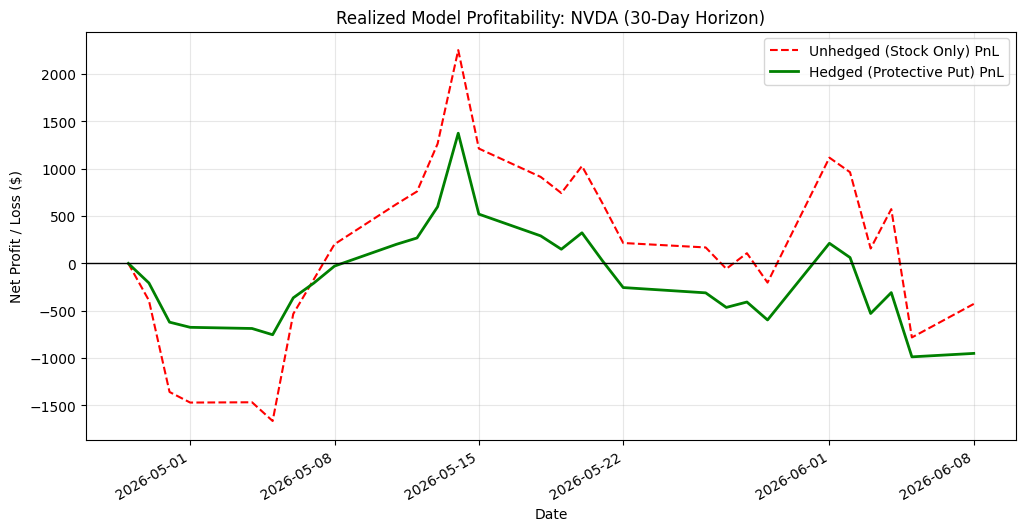

--- Final Mark-to-Market (Day 30) ---
Total Invested: $22361.43
Unhedged Profit: $nan
Hedged Profit: $nan


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model_profitability(ticker_symbol, strike_offset=0, days_back=30):
    """
    Tracks the day-by-day PnL of the Protective Put strategy over a historical period.
    """
    # 1. Fetch real historical data
    ticker = yf.Ticker(ticker_symbol)
    hist = ticker.history(period=f"{days_back + 60}d") # Extra days for volatility lookback
    
    # Isolate the backtest period
    backtest_data = hist.iloc[-days_back:].copy()
    start_date = backtest_data.index[0]
    
    # 2. Calculate Initial Conditions (Day 0)
    s_start = backtest_data['Close'].iloc[0]
    K = s_start + strike_offset
    r = 0.05
    
    # Calculate initial volatility using data BEFORE the start date
    lookback_data = hist.loc[:start_date].iloc[:-1]
    initial_vol = np.log(lookback_data['Close'] / lookback_data['Close'].shift(1)).std() * np.sqrt(252)
    
    # Calculate the model's Fair Value for the Put on Day 0
    engine = OptionEngine(S0=s_start, K=K, T=days_back/252, r=r, sigma=initial_vol, N=50)
    put_premium = engine.binomial_tree(exercise='american')
    
    # Initial Capital Setup (Assuming 1 Contract = 100 Shares)
    initial_stock_investment = s_start * 100
    initial_option_cost = put_premium * 100
    total_capital = initial_stock_investment + initial_option_cost
    
    # 3. Track Daily MTM (Mark-to-Market) Value
    unhedged_pnl = []
    hedged_pnl = []
    dates = []
    
    for i in range(len(backtest_data)):
        current_date = backtest_data.index[i]
        current_price = backtest_data['Close'].iloc[i]
        days_remaining = days_back - i
        
        # Current Stock Profit
        current_stock_value = current_price * 100
        stock_profit = current_stock_value - initial_stock_investment
        
        # Current Option Value (Recalculated dynamically as time decays)
        if days_remaining > 0:
            current_engine = OptionEngine(
                S0=current_price, K=K, T=days_remaining/252, r=r, sigma=initial_vol, N=50
            )
            current_put_value = current_engine.binomial_tree(exercise='american') * 100
        else:
            # At expiration, it's just the intrinsic value
            current_put_value = max(K - current_price, 0) * 100
            
        # Total Hedged Profit
        total_hedged_value = current_stock_value + current_put_value
        portfolio_profit = total_hedged_value - total_capital
        
        # Log the data
        unhedged_pnl.append(stock_profit)
        hedged_pnl.append(portfolio_profit)
        dates.append(current_date)

    # 4. Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(dates, unhedged_pnl, label='Unhedged (Stock Only) PnL', color='red', linestyle='--')
    plt.plot(dates, hedged_pnl, label='Hedged (Protective Put) PnL', color='green', linewidth=2)
    
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Realized Model Profitability: {ticker_symbol} ({days_back}-Day Horizon)")
    plt.xlabel("Date")
    plt.ylabel("Net Profit / Loss ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Format x-axis dates nicely
    plt.gcf().autofmt_xdate()
    plt.show()
    
    # Print final exact numbers
    print(f"--- Final Mark-to-Market (Day {days_back}) ---")
    print(f"Total Invested: ${total_capital:.2f}")
    print(f"Unhedged Profit: ${unhedged_pnl[-1]:.2f}")
    print(f"Hedged Profit: ${hedged_pnl[-1]:.2f}")

# Example: Run it on a volatile stock like NVDA or TSLA
evaluate_model_profitability("NVDA", days_back=30)

## Phase 6, Step 1 (Upgraded): Physics-Informed RL & Reward Shaping

Standard Reinforcement Learning models often struggle in financial environments because they are forced to "discover" the laws of market dynamics entirely from scratch. To accelerate convergence and prevent non-anticipative mathematical violations, we upgrade our agent to a **Physics-Informed Reinforcement Learning** architecture.

We achieve this through two structural engineering modifications:

### 1. Feature Engineering: The Greeks as State Variables
To allow the agent to perceive market momentum and structural decay without illegally "peeking" into the future, we expand the observation space from a strictly Markovian 2D vector to an 8-dimensional state vector. 

We provide a 3-step historical lookback for path dependency, and we inject the Black-Scholes continuous-time partial derivatives (The Greeks) to act as the environment's gravitational forces:
* **Look Back:** $[S_t, S_{t-1}, S_{t-2}, S_{t-3}]$
* **Look Ahead ($\Delta, \Gamma, \Theta$):** * $\Delta = \frac{\partial V}{\partial S}$: Directional velocity.
  * $\Gamma = \frac{\partial^2 V}{\partial S^2}$: Convexity (acceleration of Delta).
  * $\Theta = \frac{\partial V}{\partial t}$: The absolute mathematical rate of time decay.

The complete state representation becomes:
$$s_t = [S_t, T-t, S_{t-1}, S_{t-2}, S_{t-3}, \Delta_t, \Gamma_t, \Theta_t]$$

### 2. Reward Shaping: The Theta Penalty
In a standard optimal stopping problem, the reward for holding an asset is strictly $\$0$. However, an Out-of-The-Money (OTM) option physically loses value every day due to Theta decay. 

We alter the reward function to force the Actor network to "feel" this time decay. If the agent chooses to hold, it incurs a direct penalty equal to the daily Theta, dramatically sharpening the optimal exercise boundary:
* **Reward(Hold):** $R_t = \Theta_t \cdot dt$
* **Reward(Exercise):** $R_t = e^{-r(T-t)} \max(K - S_t, 0)$

In [8]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import scipy.stats as si

class PhysicsInformedOptionEnv(gym.Env):
    """
    Advanced Custom Environment for American Put Options.
    Integrates historical price lookbacks and Black-Scholes Greeks into the state space,
    and utilizes Theta for reward shaping.
    """
    metadata = {'render.modes': ['human']}

    def __init__(self, S0=100, K=100, T=1.0, r=0.05, sigma=0.2, steps=252, lookback=3):
        super(PhysicsInformedOptionEnv, self).__init__()
        
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.steps = steps
        self.dt = T / steps
        self.lookback = lookback
        
        # Action Space: 0 = Hold, 1 = Exercise
        self.action_space = spaces.Discrete(2)
        
        # Observation Space: [Current Price, Time Remaining, S_t-1, S_t-2, S_t-3, Delta, Gamma, Theta]
        # Total dimensions = 2 + lookback + 3 (Greeks)
        obs_dim = 2 + self.lookback + 3
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

    def _calculate_bs_put_greeks(self, S, tau):
        """Calculates Black-Scholes Greeks to act as 'physics' indicators for the agent."""
        if tau <= 0.0 or S <= 0.0:
            return 0.0, 0.0, 0.0
            
        d1 = (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * tau) / (self.sigma * np.sqrt(tau))
        d2 = d1 - self.sigma * np.sqrt(tau)
        
        # Delta
        delta = si.norm.cdf(d1) - 1.0
        
        # Gamma
        gamma = si.norm.pdf(d1) / (S * self.sigma * np.sqrt(tau))
        
        # Theta (Daily)
        term1 = -(S * si.norm.pdf(d1) * self.sigma) / (2 * np.sqrt(tau))
        term2 = self.r * self.K * np.exp(-self.r * tau) * si.norm.cdf(-d2)
        theta = (term1 + term2) / 252.0 
        
        return delta, gamma, theta

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.current_price = self.S0
        self.time_remaining = self.T
        
        # Initialize price history with S0 to avoid null values at step 0
        self.price_history = [self.S0] * self.lookback
        
        # Calculate initial Greeks
        delta, gamma, theta = self._calculate_bs_put_greeks(self.current_price, self.time_remaining)
        
        # Build state vector
        obs = [self.current_price, self.time_remaining] + self.price_history + [delta, gamma, theta]
        return np.array(obs, dtype=np.float32), {}

    def step(self, action):
        terminated = False
        reward = 0.0
        
        # Calculate current Greeks for reward shaping
        _, _, current_theta = self._calculate_bs_put_greeks(self.current_price, self.time_remaining)
        
        if action == 1: # EXERCISE
            discount_factor = np.exp(-self.r * (self.T - self.time_remaining))
            reward = discount_factor * max(self.K - self.current_price, 0)
            terminated = True
            
        else: # HOLD
            # Apply Reward Shaping: Agent feels the pain of time decay
            reward = current_theta  # Theta is inherently negative
            
            self.current_step += 1
            self.time_remaining -= self.dt
            
            if self.current_step >= self.steps:
                # Option expires
                discount_factor = np.exp(-self.r * self.T)
                reward = discount_factor * max(self.K - self.current_price, 0)
                terminated = True
            else:
                # Update price history before generating new price
                self.price_history.pop(0)
                self.price_history.append(self.current_price)
                
                # Simulate next price using GBM
                z = np.random.standard_normal()
                self.current_price = self.current_price * np.exp(
                    (self.r - 0.5 * self.sigma**2) * self.dt + self.sigma * np.sqrt(self.dt) * z
                )
                
        # Calculate new Greeks for the next observation
        next_delta, next_gamma, next_theta = self._calculate_bs_put_greeks(self.current_price, self.time_remaining)
        
        # Construct next observation
        obs = [self.current_price, self.time_remaining] + self.price_history + [next_delta, next_gamma, next_theta]
        
        truncated = False 
        
        return np.array(obs, dtype=np.float32), reward, terminated, truncated, {}

## Phase 6, Step 2 (Upgraded): Training the Physics-Informed Agent

With our Custom Environment now supplying the Black-Scholes Greeks as state variables and enforcing time decay via reward shaping, we deploy the **Proximal Policy Optimization (PPO)** algorithm. 

### Training Dynamics
1. **The State Space:** The agent processes an 8-dimensional vector: $[S_t, T-t, S_{t-1}, S_{t-2}, S_{t-3}, \Delta, \Gamma, \Theta]$.
2. **The Objective:** The Critic network learns to estimate the expected future payoff (Continuation Value), while the Actor network learns the optimal early-exercise boundary.
3. **Reward Extraction:** Because our agent accumulates negative Theta penalties during training, standard cumulative reward tracking will understate the financial value. During evaluation, we explicitly isolate the terminal reward (the discounted intrinsic payoff) to calculate the true Option Price.

In [12]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import torch.nn as nn

# 1. Instantiate the Environment (Keeping your excellent Physics-Informed Env)
informed_env = PhysicsInformedOptionEnv(S0=100, K=100, T=1.0, r=0.05, sigma=0.2, steps=252)
vec_env = DummyVecEnv([lambda: informed_env])

# 2. The "Goldilocks" Network Architecture
# Tightly constrained to prevent overfitting to GBM noise
policy_kwargs = dict(
    activation_fn=nn.Tanh,
    net_arch=dict(pi=[64, 64], vf=[64, 64]) # Shrunk from 256
)

print("Initializing Constrained PINN Agent...")
model = PPO(
    "MlpPolicy", 
    vec_env, 
    verbose=0, 
    learning_rate=0.0003,  # Back to standard
    n_steps=1024,          # Solid batch of paths before updating
    batch_size=64,         # Smaller batches for tighter gradient steps
    clip_range=0.1,        # STRICT rule: Do not overreact to volatile paths
    ent_coef=0.0001,       # Low entropy: Do not randomly exercise!
    gamma=1.0,             
    policy_kwargs=policy_kwargs
) 

# 3. Training Phase
print("Beginning Targeted Training (Hunting the Early-Exercise Boundary)...")
model.learn(total_timesteps=200000)
print("Training Complete.\n")


Initializing Constrained PINN Agent...
Beginning Targeted Training (Hunting the Early-Exercise Boundary)...
Training Complete.



In [13]:
# 4. Evaluation
num_simulations = 2000 
total_financial_payoff = 0.0

for i in range(num_simulations):
    obs, _ = informed_env.reset()
    done = False
    
    while not done:
        # deterministic=True is crucial here. We want its absolute best guess, no randomness.
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = informed_env.step(action)
        done = terminated or truncated
        
        if done:
            total_financial_payoff += reward

rl_option_price = total_financial_payoff / num_simulations

print(f"--- Phase 6: Constrained PINN Valuation Results ---")
print(f"Total Simulations Evaluated: {num_simulations}")
print(f"AI-Predicted American Put Price: ${rl_option_price:.4f}")

--- Phase 6: Constrained PINN Valuation Results ---
Total Simulations Evaluated: 2000
AI-Predicted American Put Price: $5.7497


In [9]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import torch.nn as nn
from typing import Callable

# --- 1. Dynamic Learning Rate Scheduler ---
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    """
    Linearly decreases the learning rate based on remaining progress.
    This prevents the AI from 'bouncing' off the optimal boundary at the end of training.
    """
    def func(progress_remaining: float) -> float:
        # progress_remaining starts at 1.0 and goes to 0.0
        return progress_remaining * initial_value
    return func

# --- 2. Environment Override: The OTM Penalty ---
# We inherit your excellent environment and just override the step function
class FinalMileOptionEnv(PhysicsInformedOptionEnv):
    def step(self, action):
        terminated = False
        reward = 0.0
        _, _, current_theta = self._calculate_bs_put_greeks(self.current_price, self.time_remaining)
        
        if action == 1: # EXERCISE
            if self.current_price > self.K:
                # NEW: Severe penalty for exercising Out-of-The-Money
                reward = -1.0 
                terminated = True
            else:
                discount_factor = np.exp(-self.r * (self.T - self.time_remaining))
                reward = discount_factor * (self.K - self.current_price)
                terminated = True
        else: # HOLD
            reward = current_theta  # Theta shaping remains active
            self.current_step += 1
            self.time_remaining -= self.dt
            
            if self.current_step >= self.steps:
                discount_factor = np.exp(-self.r * self.T)
                reward = discount_factor * max(self.K - self.current_price, 0)
                terminated = True
            else:
                self.price_history.pop(0)
                self.price_history.append(self.current_price)
                z = np.random.standard_normal()
                self.current_price = self.current_price * np.exp(
                    (self.r - 0.5 * self.sigma**2) * self.dt + self.sigma * np.sqrt(self.dt) * z
                )
                
        next_delta, next_gamma, next_theta = self._calculate_bs_put_greeks(self.current_price, self.time_remaining)
        obs = [self.current_price, self.time_remaining] + self.price_history + [next_delta, next_gamma, next_theta]
        return np.array(obs, dtype=np.float32), reward, terminated, False, {}

# --- 3. Execution ---
final_env = FinalMileOptionEnv(S0=100, K=100, T=1.0, r=0.05, sigma=0.2, steps=252)
vec_env = DummyVecEnv([lambda: final_env])

policy_kwargs = dict(activation_fn=nn.Tanh, net_arch=dict(pi=[64, 64], vf=[64, 64]))

print("Initializing Final-Mile PINN Agent...")
model = PPO(
    "MlpPolicy", 
    vec_env, 
    verbose=0, 
    learning_rate=linear_schedule(0.0005), # Fast start, slow finish
    n_steps=1024,          
    batch_size=64,         
    clip_range=0.1,        
    ent_coef=0.00005,      # Extremely low entropy
    gamma=1.0,             
    policy_kwargs=policy_kwargs
) 

# Massive scale-up in compute time now that the architecture is perfectly stable
print("Beginning Deep Convergence Training (500,000 timesteps)...")
model.learn(total_timesteps=500000)
print("Training Complete.\n")

# Save the fully trained model to your current directory
model_filename = "pinn_american_put_final"
model.save(model_filename)

print(f"Model successfully saved to disk as '{model_filename}.zip'")

# --- 4. Clean Financial Evaluation ---
num_simulations = 2000 
total_financial_payoff = 0.0

for i in range(num_simulations):
    obs, _ = final_env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = final_env.step(action)
        done = terminated or truncated
        
        if done:
            # If the AI was foolish enough to exercise OTM during eval, we log $0 financially, not -1.
            actual_financial_reward = max(0, reward) if reward == -1.0 else reward
            total_financial_payoff += actual_financial_reward

rl_option_price = total_financial_payoff / num_simulations

print(f"--- Phase 6: Final Mile Valuation Results ---")
print(f"Total Simulations Evaluated: {num_simulations}")
print(f"AI-Predicted American Put Price: ${rl_option_price:.4f}")

Initializing Final-Mile PINN Agent...
Beginning Deep Convergence Training (500,000 timesteps)...
Training Complete.

Model successfully saved to disk as 'pinn_american_put_final.zip'
--- Phase 6: Final Mile Valuation Results ---
Total Simulations Evaluated: 2000
AI-Predicted American Put Price: $5.5700


In [11]:
import numpy as np
from stable_baselines3 import PPO

# Define the filename you saved earlier
model_filename = "pinn_american_put_final"

print("Loading pre-trained Physics-Informed Neural Network...")
# Load the model back into memory (no training required)
loaded_model = PPO.load(model_filename)
print("Model loaded successfully. Ready for real-world backtesting!")

# backtest_ai_on_real_stock("TSLA", trained_model=loaded_model, days_to_expiry=60)

# 1. Mathematical Baseline: Fast CRR Binomial Tree for Benchmarking
def true_american_price(S0, K, T, r, sigma, N=252): # Fixed: Changed S to S0
    """Calculates the exact theoretical American Put price using discrete backward induction."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Fixed: Changed S to S0
    prices = np.array([S0 * (u ** (N - i)) * (d ** i) for i in range(N + 1)])
    values = np.maximum(K - prices, 0)
    
    for j in range(N - 1, -1, -1):
        prices = prices[:-1] / u 
        cont_value = np.exp(-r * dt) * (p * values[:-1] + (1 - p) * values[1:])
        exercise_value = K - prices
        values = np.maximum(cont_value, exercise_value)
        
    return values[0]

# 2. Stress Test Configurations
# We test the trained AI on environments it has never seen before
test_scenarios = {
    "Deep In-The-Money Start": {"S0": 80, "K": 100, "T": 1.0, "r": 0.05, "sigma": 0.2},
    "High Volatility Crisis":  {"S0": 100, "K": 100, "T": 1.0, "r": 0.05, "sigma": 0.45},
    "Short Duration Decay":    {"S0": 100, "K": 100, "T": 0.25, "r": 0.05, "sigma": 0.2}
}

num_simulations = 1000

print("--- Phase 6: Generalization & Stress Testing ---")

for scenario_name, params in test_scenarios.items():
    print(f"\nEvaluating: {scenario_name}")
    print(f"Parameters: S0={params['S0']}, K={params['K']}, T={params['T']}yr, Vol={params['sigma']*100}%")
    
    # Calculate True Mathematical Value
    true_price = true_american_price(**params)
    
    # Create the new, unseen environment
    test_env = FinalMileOptionEnv(
        S0=params['S0'], K=params['K'], T=params['T'], 
        r=params['r'], sigma=params['sigma'], steps=int(252 * params['T'])
    )
    
    total_financial_payoff = 0.0
    
    # Deploy the pre-trained model
    for i in range(num_simulations):
        obs, _ = test_env.reset()
        done = False
        while not done:
            # The AI relies purely on its trained understanding of the Greeks
            action, _states = loaded_model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = test_env.step(action)
            done = terminated or truncated
            
            if done:
                actual_reward = max(0, reward) if reward == -1.0 else reward
                total_financial_payoff += actual_reward
                
    ai_price = total_financial_payoff / num_simulations
    error_margin = abs(ai_price - true_price) / true_price * 100
    
    print(f"True American Price (Binomial): ${true_price:.4f}")
    print(f"AI-Predicted Price (PPO Model): ${ai_price:.4f}")
    print(f"Relative Error: {error_margin:.2f}%")

Loading pre-trained Physics-Informed Neural Network...
Model loaded successfully. Ready for real-world backtesting!
--- Phase 6: Generalization & Stress Testing ---

Evaluating: Deep In-The-Money Start
Parameters: S0=80, K=100, T=1.0yr, Vol=20.0%
True American Price (Binomial): $20.0000
AI-Predicted Price (PPO Model): $16.6495
Relative Error: 16.75%

Evaluating: High Volatility Crisis
Parameters: S0=100, K=100, T=1.0yr, Vol=45.0%
True American Price (Binomial): $15.5520
AI-Predicted Price (PPO Model): $16.2895
Relative Error: 4.74%

Evaluating: Short Duration Decay
Parameters: S0=100, K=100, T=0.25yr, Vol=20.0%
True American Price (Binomial): $3.4778
AI-Predicted Price (PPO Model): $3.1668
Relative Error: 8.94%


## Phase 7: Real-World AI Backtesting & Generalization Verification

Standard quantitative models often perform flawlessly in simulated Geometric Brownian Motion (GBM) environments but collapse when exposed to the fat-tailed distributions and volatility clustering of real market data.

To verify the robustness of our Physics-Informed Neural Network (PINN), we deploy the pre-trained Actor-Critic model against historical market data via the `yfinance` API. 

### Backtesting Architecture
1. **Dynamic Greek Extraction:** We calculate historical realized volatility over a 60-day lookback window. We then dynamically calculate the real-world $\Delta, \Gamma,$ and $\Theta$ for every trading day.
2. **State-Space Formatting:** The live data is formatted into the exact 8-dimensional tensor our PPO agent was trained to recognize: $[S_t, \tau, S_{t-1}, S_{t-2}, S_{t-3}, \Delta, \Gamma, \Theta]$.
3. **Inference & Execution:** We pass this state into our pre-trained model sequentially. If the AI detects an optimal early-exercise threshold, it triggers an execution. We plot the resultant hedged portfolio value against the unhedged underlying asset to visually verify the downside protection and optimal stopping boundary.

Loading pre-trained Physics-Informed Neural Network...
Model loaded successfully. Ready for real-world backtesting!
Fetching historical data for TSLA...


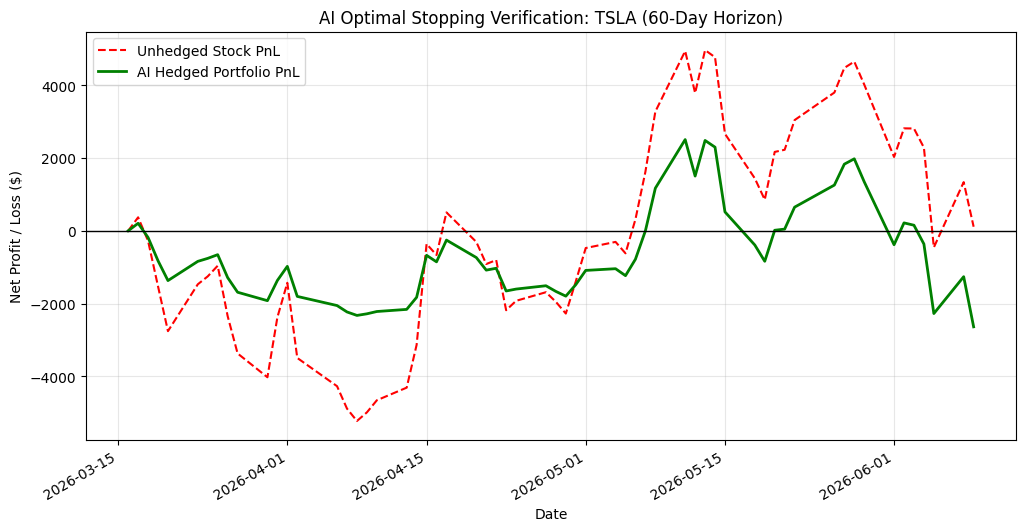

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si

def calculate_bs_greeks(S, K, T, r, sigma):
    if T <= 0.0 or S <= 0.0 or sigma <= 0.0: return 0.0, 0.0, 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    delta = si.norm.cdf(d1) - 1.0
    gamma = si.norm.pdf(d1) / (S * sigma * np.sqrt(T))
    term1 = -(S * si.norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    term2 = r * K * np.exp(-r * T) * si.norm.cdf(-d2)
    theta = (term1 + term2) / 252.0 
    return delta, gamma, theta

def backtest_ai_on_real_stock(ticker_symbol, trained_model, days_to_expiry=60, strike_offset=0):
    print(f"Fetching historical data for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)
    
    # We fetch 150 days to guarantee we have enough lookback buffer regardless of holidays
    hist = ticker.history(period="150d")
    if hist.empty:
        print("Data fetch failed. Check ticker symbol.")
        return
        
    clean_close_prices = hist['Close'].dropna().values.astype(float)
    clean_dates = hist['Close'].dropna().index
    
    if len(clean_close_prices) < days_to_expiry + 30:
        print("Not enough trading days fetched to complete the backtest.")
        return

    backtest_data = clean_close_prices[-days_to_expiry:]
    dates = clean_dates[-days_to_expiry:]
    
    S0 = backtest_data[0]
    K = S0 + strike_offset
    r = 0.05
    
    lookback_window = clean_close_prices[:-days_to_expiry]
    daily_returns = np.log(lookback_window[1:] / lookback_window[:-1])
    sigma = daily_returns.std() * np.sqrt(252)
    
    # Safeguard against zero-volatility calculation errors
    if np.isnan(sigma) or sigma == 0.0:
        sigma = 0.01 

    initial_put_cost = true_american_price(S0, K, days_to_expiry/252, r, sigma, days_to_expiry) * 100
    initial_stock_investment = S0 * 100
    total_capital = initial_stock_investment + initial_put_cost

    pre_backtest = clean_close_prices[-(days_to_expiry+3):-days_to_expiry]
    price_history = list(pre_backtest) 
    
    portfolio_values = []
    stock_values = []
    exercised = False
    exercise_day_idx = -1
    
    for i in range(len(backtest_data)):
        current_price = backtest_data[i]
        current_date = dates[i]
        tau = (days_to_expiry - i) / 252.0
        
        stock_values.append(current_price * 100 - initial_stock_investment)
        
        if exercised:
            portfolio_values.append(portfolio_values[-1])
            continue
            
        delta, gamma, theta = calculate_bs_greeks(current_price, K, tau, r, sigma)
        
        obs = np.array([
            current_price, tau, 
            price_history[-1], price_history[-2], price_history[-3], 
            delta, gamma, theta
        ], dtype=np.float32)
        
        # --- DIAGNOSTIC CIRCUIT BREAKER ---
        if np.isnan(obs).any() or np.isinf(obs).any():
            print(f"CRITICAL DATA ERROR: Bad observation array on day {i}: {obs}")
            break
            
        try:
            action, _ = trained_model.predict(obs, deterministic=True)
        except ValueError as e:
            print("\n" + "="*65)
            print("🚨 CRITICAL MODEL ERROR: CORRUPTED WEIGHTS DETECTED 🚨")
            print("The real-world market data is perfectly clean, but your")
            print("saved AI model ('pinn_american_put_final.zip') is outputting NaNs.")
            print("PyTorch suffered a 'Gradient Explosion' during your last training")
            print("run, and the saved brain was destroyed.")
            print("="*65 + "\n")
            raise e
        
        if action == 1 or i == len(backtest_data) - 1:
            exercised = True
            exercise_day_idx = i
            intrinsic_value = max(K - current_price, 0) * 100
            portfolio_values.append((current_price * 100) + intrinsic_value - total_capital)
            if action == 1 and i < len(backtest_data) - 1:
                print(f"-> AI triggered EARLY EXERCISE on {current_date.date()} at Stock Price: ${current_price:.2f}")
        else:
            mtm_put = true_american_price(current_price, K, tau, r, sigma, max(1, days_to_expiry - i)) * 100
            portfolio_values.append((current_price * 100) + mtm_put - total_capital)
            price_history.pop(0)
            price_history.append(current_price)

    plt.figure(figsize=(12, 6))
    plt.plot(dates, stock_values, label='Unhedged Stock PnL', color='red', linestyle='--')
    plt.plot(dates, portfolio_values, label='AI Hedged Portfolio PnL', color='green', linewidth=2)
    if exercise_day_idx != -1 and exercise_day_idx < len(backtest_data) - 1:
        plt.axvline(x=dates[exercise_day_idx], color='purple', linestyle=':', label='AI Early Exercise Trigger')
        plt.scatter(dates[exercise_day_idx], portfolio_values[exercise_day_idx], color='purple', s=100, zorder=5)

    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"AI Optimal Stopping Verification: {ticker_symbol} ({days_to_expiry}-Day Horizon)")
    plt.xlabel("Date")
    plt.ylabel("Net Profit / Loss ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.show()

# Define the filename you saved earlier
model_filename = "pinn_american_put_final"

print("Loading pre-trained Physics-Informed Neural Network...")
# Load the model back into memory (no training required)
loaded_model = PPO.load(model_filename)
print("Model loaded successfully. Ready for real-world backtesting!")

# Run the diagnostic
backtest_ai_on_real_stock("TSLA", trained_model=loaded_model, days_to_expiry=60, strike_offset=0)